In [94]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import defaultdict
seed = 2

In [95]:
class buildClassifier:
    def __init__(self,randomstate=104):
        
        self.data = pd.read_csv(r'data/marriage.csv',header=None)
        X,Y = self.data.iloc[:,0:-1],self.data.iloc[:,-1]
        self.scaler  = StandardScaler() #https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
        X = self.scaler.fit_transform(X)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X,Y , random_state=randomstate,test_size=0.20, shuffle=True)

        self.pca = PCA(n_components=2)
        self.x_pca = self.pca.fit_transform(self.X_train)
        self.x_test_pca = self.pca.transform(self.X_test)

    def knn(self,k,pca=False):
        if pca == True:
            data_x=self.x_pca
        else:
            data_x=self.X_train
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(data_x,self.y_train)
        return knn

    def logistic_regression(self,pca=False):
        if pca == True:
            data_x=self.x_pca
        else:
            data_x=self.X_train

        log_reg_model = LogisticRegression(random_state=15)

        log_reg_model.fit(data_x,self.y_train)
        
        return log_reg_model
    def naive_bayes(self,pca=False):
        if pca == True:
            data_x=self.x_pca
        else:
            data_x=self.X_train

        naive_bayes = GaussianNB(var_smoothing=10**-3)
        naive_bayes.fit(data_x,self.y_train)
        
        return naive_bayes
    
    def get_accuracy(self,model,pca=False):
        if pca == True:
            data_x=self.x_test_pca
        else:
            data_x=self.X_test

        y_pred =model.predict(data_x)
        return accuracy_score(self.y_test,y_pred),y_pred
        



In [96]:
rng = np.random.default_rng(seed)
test_random_splits = rng.integers(1, 750, size=200).tolist()

Q4.1

In [97]:
accuracy_results_dict = defaultdict(list)
for state in test_random_splits:
    base_classifier = buildClassifier(randomstate=state)
    knn_classifier=base_classifier.knn(k=3)
    log_reg_classifier=base_classifier.logistic_regression()
    naive_bayes_classifier=base_classifier.naive_bayes()
    
    knn_classifier_accuracy,knn_classifier_prediction = base_classifier.get_accuracy(knn_classifier)
    log_reg_classifier_accuracy,log_reg_classifier_prediction = base_classifier.get_accuracy(log_reg_classifier)
    naive_bayes_classifier_accuracy,naive_bayes_classifier_prediction = base_classifier.get_accuracy(naive_bayes_classifier)

    accuracy_results_dict['knn'].append(knn_classifier_accuracy)
    accuracy_results_dict['naive_bayes'].append(naive_bayes_classifier_accuracy)
    accuracy_results_dict['logistic_regression'].append(log_reg_classifier_accuracy)

In [98]:
mean_accuracy_array = np.array([[k,np.average(v)]for k,v in accuracy_results_dict.items()], dtype=object)

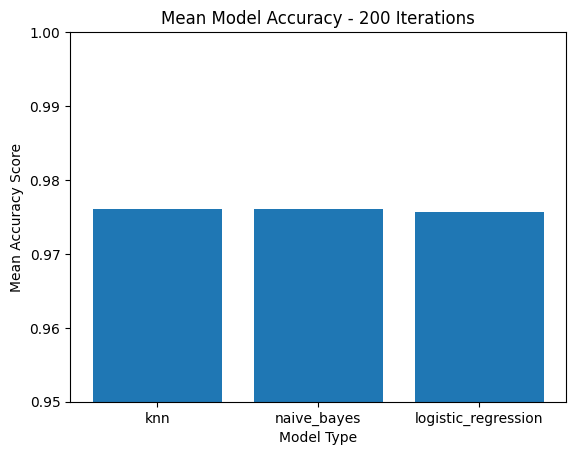

[['knn' np.float64(0.9760294117647059)]
 ['naive_bayes' np.float64(0.9760294117647059)]
 ['logistic_regression' np.float64(0.9755882352941176)]]


In [99]:
plt.bar(mean_accuracy_array[:,0],mean_accuracy_array[:,1])
plt.title('Mean Model Accuracy - 200 Iterations')
plt.xlabel("Model Type")
plt.ylabel('Mean Accuracy Score')
plt.ylim(.95, 1)
plt.show()
print(mean_accuracy_array)

Q4.2

In [100]:
accuracy_pca_results_dict = defaultdict(list)

pca_test_data,pca_y_labels = None,None
classifiers = {'knn':None,'log_reg':None,'naive_bayes':None}
prediction_dict = {'knn':None,'log_reg':None,'naive_bayes':None}

for state in test_random_splits:
    base_classifier_pca = buildClassifier(randomstate=state)
    knn_pca=base_classifier_pca.knn(k=3,pca=True)
    log_reg_pca=base_classifier_pca.logistic_regression(pca=True)
    naive_bayes_pca=base_classifier_pca.naive_bayes(pca=True)

    pca_knn_classifier_accuracy,pca_knn_classifier_prediction = base_classifier_pca.get_accuracy(knn_pca,pca=True)
    pca_log_reg_classifier_accuracy,pca_log_reg_classifier_prediction = base_classifier_pca.get_accuracy(log_reg_pca,pca=True)
    pca_naive_bayes_classifier_accuracy,pca_naive_bayes_classifier_prediction = base_classifier_pca.get_accuracy(naive_bayes_pca,pca=True)

    accuracy_pca_results_dict['knn'].append(pca_knn_classifier_accuracy)
    accuracy_pca_results_dict['naive_bayes'].append(pca_log_reg_classifier_accuracy)
    accuracy_pca_results_dict['logistic_regression'].append(pca_naive_bayes_classifier_accuracy)
    pca_test_data=base_classifier_pca.x_test_pca
    pca_y_labels = base_classifier_pca.y_test
    classifiers['knn']=knn_pca
    classifiers['log_reg']=log_reg_pca
    classifiers['naive_bayes']=naive_bayes_pca
    prediction_dict['knn']=pca_knn_classifier_prediction
    prediction_dict['log_reg']=pca_log_reg_classifier_prediction
    prediction_dict['naive_bayes']=pca_naive_bayes_classifier_prediction

    




In [101]:
mean_accuracy_pca_array = np.array([[k,np.average(v)]for k,v in accuracy_pca_results_dict.items()], dtype=object)

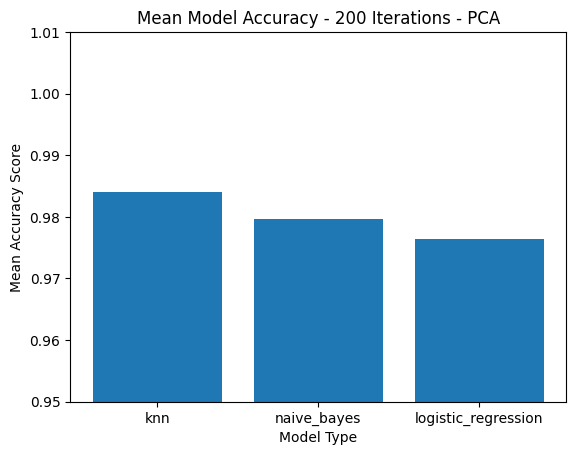

[['knn' np.float64(0.9839705882352942)]
 ['naive_bayes' np.float64(0.9797058823529413)]
 ['logistic_regression' np.float64(0.9763235294117648)]]


In [102]:
plt.bar(mean_accuracy_pca_array[:,0],mean_accuracy_pca_array[:,1])
plt.title('Mean Model Accuracy - 200 Iterations - PCA')
plt.xlabel("Model Type")
plt.ylabel('Mean Accuracy Score')
plt.ylim(.95, 1.01)
plt.show()
print(mean_accuracy_pca_array)

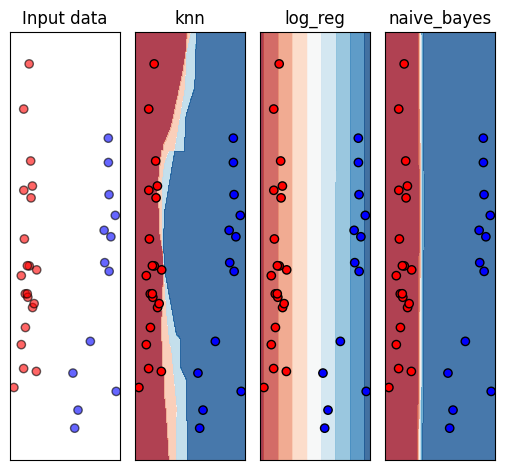

In [106]:
j=1


x_min, x_max = pca_test_data[:, 0].min() - .5, pca_test_data[:, 0].max() + .5
y_min, y_max = pca_test_data[:, 1].min() - .5, pca_test_data[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02),
                        np.arange(y_min, y_max, .02))

cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])


ax = plt.subplot(1, len(classifiers.keys())+2,j)

ax.set_title("Input data")

ax.scatter(pca_test_data[:, 0], pca_test_data[:, 1], c=pca_y_labels, cmap=cm_bright, alpha=0.6,
            edgecolors='k')

ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())

ax.set_xticks(())
ax.set_yticks(())

j+=1
for i, (name, clf) in enumerate(classifiers.items()):
    if hasattr(clf, "decision_function"):
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

    ax = plt.subplot(1, len(classifiers.keys())+2 , j)
    ax.set_title(name)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)
    ax.scatter(pca_test_data[:, 0], pca_test_data[:, 1], c=pca_y_labels, cmap=cm_bright,
                edgecolors='k')
    j+=1
        
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
            
plt.tight_layout()
plt.show()



        
# i += 1